# NO₂ Plume Algorithm Panels — Step-by-Step Visualization

Per-snapshot panels illustrating the automated plume-labeling algorithm
(Figure 4 in the paper). Each panel adds one element on top of the previous,
showing how the algorithm builds up its decision:

1. **NO₂ alone** — raw TROPOMI tropospheric column
2. **+ Cities** — overlay nearby cities (orange circles)
3. **+ Power plants** — overlay nearby plants (green triangles)
4. **+ Interference zones** — masked regions around cities (cyan) and other plants (magenta)
5. **+ Downwind plume zone** — the wedge in which a plume can be attributed to the target plant

Plus a standalone vertical colorbar for paper assembly.

**Paths (paper revision)** — 100 m wind + LST-fixed:
- US emission table: `pipeline_100m_run/Run_100m_20260414/...augmented_localtz.csv`
- Plants: `data/us/power_plants_with_combined_nearby_stats_parallel_debug.csv`
- Cities: `data/world/worldcities.csv`
- Output: `results/paper_figures/no2_*.png`

**Note**: Snapshot index `57` is from the original Run_500 csv. With the
LST-fix the row order may have changed slightly; pick a different index if the
target plant doesn't render correctly.


In [39]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import colors
import netCDF4 as nc
from pyproj import Geod
from math import log10, sqrt, atan2, degrees, radians, cos
from matplotlib import font_manager as fm
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import RANSACRegressor
from types import SimpleNamespace

plt.rcdefaults()
plt.rcParams['figure.facecolor'] = 'white'

# ── Font: Nimbus Roman, non-bold/non-italic ────────────────────────────────
nimbus_path = None
for path in fm.findSystemFonts():
    pl = path.lower()
    if ('nimbusroman' in pl or 'nimbus_roman' in pl) and 'bold' not in pl and 'italic' not in pl and 'oblique' not in pl:
        nimbus_path = path
        break
prop = fm.FontProperties(fname=nimbus_path, size=22) if nimbus_path else fm.FontProperties(size=22)
print(f'Font: {nimbus_path or "default sans-serif"}')

# ── Paths (paper revision, 100 m wind + LST-fixed) ─────────────────────────
US_HOURLY_CSV = '/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/Run_100m_20260414/updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv'
PLANTS_PATH   = '/net/fs06/d3/rzhuang/TROPOMI/data/us/power_plants_with_combined_nearby_stats_parallel_debug.csv'
CITIES_PATH   = '/net/fs06/d3/rzhuang/TROPOMI/data/world/worldcities.csv'
OUTPUT_DIR    = '/net/fs06/d3/rzhuang/TROPOMI/results/paper_figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Plot config ────────────────────────────────────────────────────────────
INDICES = [65]   # snapshot row indices to render (Oak Grove plant 6180, 2022-07-26 19:25 UTC; OLD Run_500 row 57 → new csv row 65)
BOX_DEG = 0.6    # half-width/height of plotting window (degrees)
PAD     = 0      # extra cells around the detected window

# ── Interference parameters (mirror plotting helper used in stage-2 labelling) ─
INTERF_MAX_DISTANCE_KM = 150.0
INTERF_CITY_POP_THRESH = 200000.0
INTERF_PLANT_EMIS_THRESH = 1.0
CITY_BASE_RADIUS = 0.0
CITY_POP_SCALE = 9.0
CITY_RADIUS_MIN = 10.0
CITY_RADIUS_MAX = 90.0
CLOSE_DISTANCE_KM_MASK = 20.0
KM_PER_DEG_LAT = 111.1

# ── Background-zone parameters (mirror stage-2 labelling) ──────────────────
BG_DIST_MIN_KM = 10.0
BG_DIST_MAX_KM = 100.0
BG_ANGLE_TOLERANCE_DEG = 60.0

Font: /usr/share/fonts/urw-base35/NimbusRoman-Regular.otf


In [40]:
# ── Helpers ────────────────────────────────────────────────────────────────
def create_geodesic_circle(center_lon, center_lat, radius_km, num_points=100):
    """Geodesic circle (returns lons, lats) for a given centre + radius."""
    geod = Geod(ellps='WGS84')
    az = np.linspace(0, 360, num_points)
    lons, lats, _ = geod.fwd(
        np.full(num_points, center_lon), np.full(num_points, center_lat),
        az, np.full(num_points, radius_km * 1000.0))
    return lons, lats

def prepare_interfering_sources(target_lat, target_lon, target_plant_id,
                                all_plants_df, cities_df):
    """Identify potential interfering sources (cities + power plants) near a target."""
    if pd.isna(target_lat) or pd.isna(target_lon):
        return []
    geod = Geod(ellps='WGS84')
    out = []

    # Cities
    if cities_df is not None and not cities_df.empty:
        cities_df['population'] = pd.to_numeric(cities_df['population'], errors='coerce').fillna(0)
        in_box = cities_df[(cities_df['latitude'].between(target_lat - 2, target_lat + 2)) &
                           (cities_df['longitude'].between(target_lon - 2, target_lon + 2))].copy()
        for _, c in in_box.iterrows():
            if c['population'] < INTERF_CITY_POP_THRESH:
                continue
            dist_km = geod.inv(target_lon, target_lat, c['longitude'], c['latitude'])[2] / 1000.0
            if dist_km <= INTERF_MAX_DISTANCE_KM:
                radius = CITY_BASE_RADIUS + CITY_POP_SCALE * log10(max(1, c['population']))
                out.append({'type': 'city',
                            'lat': c['latitude'], 'lon': c['longitude'],
                            'radius_km': max(CITY_RADIUS_MIN, min(radius, CITY_RADIUS_MAX)),
                            'name': c['name']})

    # Power plants
    if all_plants_df is not None and not all_plants_df.empty:
        target_info = all_plants_df[all_plants_df['Facility Name'] == target_plant_id]
        annual_nox = 0
        if not target_info.empty and 'NOx Mass (short tons)' in target_info.columns:
            v = target_info.iloc[0]['NOx Mass (short tons)']
            if pd.notna(v):
                annual_nox = v
        thresh = INTERF_PLANT_EMIS_THRESH * annual_nox
        others = all_plants_df[all_plants_df['Facility Name'] != target_plant_id].copy()
        in_box = others[(others['Latitude'].between(target_lat - 2, target_lat + 2)) &
                        (others['Longitude'].between(target_lon - 2, target_lon + 2))].copy()
        for _, p in in_box.iterrows():
            if 'NOx Mass (short tons)' not in p or pd.isna(p['NOx Mass (short tons)']) \
                    or p['NOx Mass (short tons)'] < thresh:
                continue
            dist_km = geod.inv(target_lon, target_lat, p['Longitude'], p['Latitude'])[2] / 1000.0
            if dist_km <= INTERF_MAX_DISTANCE_KM:
                out.append({'type': 'plant',
                            'lat': p['Latitude'], 'lon': p['Longitude'],
                            'radius_km': 0,
                            'name': p['Facility Name']})
    return out

def deg_to_cardinal(d):
    """Meteorological angle → cardinal direction (N, NE, E, SE, ...)."""
    dirs = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
    return dirs[int(round(d / 45)) % 8]

def resolve_target_plant_name(ref_lat, ref_lon, plants_df):
    """Return the facility name of the plant closest to (ref_lat, ref_lon)."""
    exact = plants_df[(plants_df['Latitude'] == ref_lat) &
                      (plants_df['Longitude'] == ref_lon)]
    if not exact.empty:
        return exact.iloc[0]['Facility Name']
    geod = Geod(ellps='WGS84')
    best, best_dist = None, float('inf')
    for _, plant in plants_df.iterrows():
        d = geod.inv(ref_lon, ref_lat, plant['Longitude'], plant['Latitude'])[2]
        if d < best_dist and d < 1000:
            best_dist = d
            best = plant
    return best['Facility Name'] if best is not None else None

def load_swath(file_path):
    """Read TROPOMI lat/lon/NO2 arrays (squeezed to 2-D)."""
    with nc.Dataset(file_path) as ds:
        grp = ds.groups.get('PRODUCT', ds)
        lat = grp.variables['latitude'][:]
        lon = grp.variables['longitude'][:]
        no2 = grp.variables['nitrogendioxide_tropospheric_column'][:]
        if lat.ndim > 2:
            lat, lon, no2 = lat[0], lon[0], no2[0]
    return lat, lon, no2

def slice_window(lat, lon, x_min, x_max, y_min, y_max):
    """Find the row/col range that covers a lat/lon box (with 0.2° padding)."""
    mask = (lat >= y_min - 0.2) & (lat <= y_max + 0.2) & (lon >= x_min - 0.2) & (lon <= x_max + 0.2)
    if not mask.any():
        return None
    r, c = np.where(mask)
    r0, r1 = max(r.min() - PAD, 0), min(r.max() + PAD, lat.shape[0] - 1)
    c0, c1 = max(c.min() - PAD, 0), min(c.max() + PAD, lon.shape[1] - 1)
    return r0, r1, c0, c1


# ── Geometric helpers (background-zone visualization) ─────────────────────
def create_geodesic_arc(center_lon, center_lat, radius_km, start_az, end_az, num_points=50):
    """Lon/lat arrays for an arc at radius_km between two azimuths."""
    geod = Geod(ellps='WGS84')
    if end_az < start_az:
        az = np.concatenate([np.linspace(start_az, 360, num_points // 2),
                             np.linspace(0, end_az, num_points // 2)])
    else:
        az = np.linspace(start_az, end_az, num_points)
    lons, lats, _ = geod.fwd(np.full(len(az), center_lon),
                             np.full(len(az), center_lat),
                             az, np.full(len(az), radius_km * 1000.0))
    return lons, lats

def create_radial_line(center_lon, center_lat, az, start_km, end_km, num_points=20):
    """Lon/lat arrays for a radial line at a given azimuth."""
    geod = Geod(ellps='WGS84')
    distances_m = np.linspace(start_km * 1000, end_km * 1000, num_points)
    lons, lats, _ = geod.fwd(np.full(num_points, center_lon),
                             np.full(num_points, center_lat),
                             np.full(num_points, az), distances_m)
    return lons, lats

def create_annular_sector_boundary(center_lon, center_lat, inner_km, outer_km,
                                   center_az, sector_width_deg):
    """Closed boundary of an annular sector (inner arc + radial + outer arc + radial)."""
    half = sector_width_deg / 2
    start_az = (center_az - half) % 360
    end_az = (center_az + half) % 360
    inner_lon, inner_lat = create_geodesic_arc(center_lon, center_lat, inner_km, start_az, end_az)
    outer_lon, outer_lat = create_geodesic_arc(center_lon, center_lat, outer_km, start_az, end_az)
    left_lon, left_lat   = create_radial_line(center_lon, center_lat, start_az, inner_km, outer_km)
    right_lon, right_lat = create_radial_line(center_lon, center_lat, end_az, inner_km, outer_km)
    boundary_lon = np.concatenate([inner_lon, right_lon, outer_lon[::-1], left_lon[::-1]])
    boundary_lat = np.concatenate([inner_lat, right_lat, outer_lat[::-1], left_lat[::-1]])
    return boundary_lon, boundary_lat

def create_background_mask(lat_grid, lon_grid, plant_lat, plant_lon, wind_from_deg,
                           zone_of_no_plume_mask,
                           bg_dist_min_km=10.0, bg_dist_max_km=100.0,
                           bg_angle_tol_deg=60.0):
    """Boolean mask: pixel ∈ upwind annular sector, NOT in zone-of-no-plume."""
    geod = Geod(ellps='WGS84')
    if pd.isna(wind_from_deg) or pd.isna(plant_lat) or pd.isna(plant_lon):
        return np.zeros_like(lat_grid, dtype=bool)
    fwd_az, _, dist_m = geod.inv(np.full_like(lon_grid, plant_lon),
                                  np.full_like(lat_grid, plant_lat),
                                  lon_grid, lat_grid)
    dist_km = dist_m / 1000.0
    az_from_plant = (fwd_az + 360) % 360
    angular_diff = np.abs(((az_from_plant - wind_from_deg + 180) % 360) - 180)
    return ((dist_km >= bg_dist_min_km) & (dist_km <= bg_dist_max_km) &
            (angular_diff <= bg_angle_tol_deg / 2) & ~zone_of_no_plume_mask)


In [41]:
# ── Plume detection algorithm ──────────────────────────────────────────────
# Direct port of label_no2_plume_flexible_interference from
# TROPOMI_US/code/7_generate_figure.ipynb. Used by Panel 8 to overlay the
# actual detected plume mask on top of NO₂ + interference zones.

def calculate_areas(mask, lat_2d, lon_2d):
    """Estimate total area (km²) of TROPOMI pixels flagged True in mask."""
    plume_y, plume_x = np.where(mask)
    pixel_areas = []
    deg2km = 111.14
    for y, x in zip(plume_y, plume_x):
        area_est = []
        for dx in (1, -1):
            nx = x + dx
            if 0 <= nx < lon_2d.shape[1]:
                dlon = abs(lon_2d[y, nx] - lon_2d[y, x])
                for dy in (1, -1):
                    ny = y + dy
                    if 0 <= ny < lat_2d.shape[0]:
                        dlat = abs(lat_2d[ny, x] - lat_2d[y, x])
                        lat_km = dlat * deg2km
                        lon_km = dlon * deg2km * np.cos(np.radians(lat_2d[y, x]))
                        area_est.append(lat_km * lon_km)
        pixel_areas.append(np.mean(area_est) if area_est else 25.0)
    return float(np.sum(pixel_areas)) if pixel_areas else 0.0


def label_no2_plume_flexible_interference(
    full_no2, full_lon, full_lat,
    wind_u, wind_v, plant_lon, plant_lat,
    interfering_sources=None, zoom_radius_km=100,
    threshold_factor=4.5, threshold_abs_min=1e-5, threshold_radius_km=25.0,
    max_distance_km=20, close_distance_km=8, max_angle_diff=30,
    max_angle_diff_mask=90, close_distance_km_mask=2,
    flagged_area=10.0, background_mode='directional', upwind_angle_tolerance=90,
    background_dist_min_km=10, background_dist_max_km=75,
    sigma=10, stat_radius=50.0, **kwargs):
    """Core plume-detection algorithm (returns dict with plume_mask, threshold, ...)."""
    geod = Geod(ellps="WGS84")
    tol = 1e-12
    def _norm(a): return (a + 360) % 360
    def _ang_diff(a, b): return np.abs(((a - b + 180) % 360) - 180)
    def _safe_stat(arr, fn=np.nanmedian):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            val = fn(arr)
            if pd.isna(val): val = np.nanmean(arr)
        return val
    def _zoom_indices(mask, pad, shp):
        if not np.any(mask): return None
        r, c = np.where(mask)
        return (max(0, r.min() - pad), min(shp[0] - 1, r.max() + pad),
                max(0, c.min() - pad), min(shp[1] - 1, c.max() + pad))

    default = {
        "is_significant": False, "plume_mask": np.array([[]], bool),
        "background": np.array([[]]), "anomalies": np.array([[]]),
        "threshold": threshold_abs_min, "plume_area_km2": 0.0,
        "plume_direction_to_deg": np.nan, "wind_direction_from_deg": np.nan,
        "zoomed_lats": np.array([[]]), "zoomed_lons": np.array([[]]),
        "zoomed_no2": np.array([[]]),
        "lon_min": np.nan, "lon_max": np.nan, "lat_min": np.nan, "lat_max": np.nan,
        "interference_mask": np.array([[]], bool),
        "background_mode_used": background_mode,
        "no2_mean_radius": np.nan, "no2_std_radius": np.nan,
        "no2_frac_valid_radius": np.nan,
    }
    try:
        if not all(isinstance(x, np.ndarray) for x in (full_lat, full_lon, full_no2)):
            raise ValueError("Inputs must be numpy arrays.")
        if not (full_lat.shape == full_lon.shape == full_no2.shape):
            raise ValueError("Input shapes mismatch.")
        if pd.isna(plant_lat) or pd.isna(plant_lon):
            raise ValueError("Plant coordinates invalid.")

        dlat = zoom_radius_km / 111.1
        dlon = zoom_radius_km / (111.1 * max(cos(radians(plant_lat)), 1e-9))
        box_mask = ((full_lat >= plant_lat - dlat) & (full_lat <= plant_lat + dlat) &
                    (full_lon >= plant_lon - dlon) & (full_lon <= plant_lon + dlon))
        idx = _zoom_indices(box_mask, pad=2, shp=full_no2.shape)
        if idx is None: return default
        i0, i1, j0, j1 = idx
        no2 = full_no2[i0:i1+1, j0:j1+1].copy()
        lat = full_lat[i0:i1+1, j0:j1+1].copy()
        lon = full_lon[i0:i1+1, j0:j1+1].copy()
        if no2.size == 0: return default
        default.update({"zoomed_no2": no2, "zoomed_lats": lat, "zoomed_lons": lon,
                        "lat_min": np.nanmin(lat), "lat_max": np.nanmax(lat),
                        "lon_min": np.nanmin(lon), "lon_max": np.nanmax(lon)})

        # Per-pixel distance and azimuth from the target plant
        geo_mask = ~np.isnan(lat) & ~np.isnan(lon)
        dist_km = np.full_like(no2, np.nan, float)
        azm = np.full_like(no2, np.nan, float)
        if np.any(geo_mask):
            lat_flat = lat[geo_mask].flatten()
            lon_flat = lon[geo_mask].flatten()
            fwd, _, d_m = geod.inv(np.full(len(lat_flat), plant_lon),
                                   np.full(len(lat_flat), plant_lat),
                                   lon_flat, lat_flat)
            dist_km[geo_mask] = d_m / 1000.0
            azm[geo_mask] = _norm(fwd)

        u = np.nanmean(wind_u) if isinstance(wind_u, (np.ndarray, list, pd.Series)) else wind_u
        v = np.nanmean(wind_v) if isinstance(wind_v, (np.ndarray, list, pd.Series)) else wind_v
        if pd.isna(u) or pd.isna(v) or (abs(u) < tol and abs(v) < tol):
            wind_to, wind_from = np.nan, np.nan
        else:
            wind_to = _norm(np.degrees(np.arctan2(u, v)))
            wind_from = _norm(np.degrees(np.arctan2(u, v)) + 180)
        default.update({"plume_direction_to_deg": wind_to,
                        "wind_direction_from_deg": wind_from})

        valid_no2 = (~np.isnan(no2)) & (np.abs(no2) > tol) & geo_mask
        interference = np.ones_like(no2, bool)
        if interfering_sources and np.any(geo_mask):
            lon_f, lat_f = lon[geo_mask], lat[geo_mask]
            for src in interfering_sources:
                slat, slon, rad = src.get("lat"), src.get("lon"), src.get("radius_km")
                if pd.isna(slat) or pd.isna(slon) or pd.isna(rad): continue
                az1, _, d_m_int = geod.inv(np.full_like(lon_f, slon),
                                           np.full_like(lat_f, slat),
                                           lon_f, lat_f)
                d_km_int = d_m_int / 1000.0
                in_rad = d_km_int <= rad
                if src.get("type", "city").lower() == "plant":
                    close = d_km_int <= close_distance_km_mask
                    if pd.notna(wind_to):
                        in_cone = _ang_diff(az1, wind_to) <= max_angle_diff_mask
                        in_rad = (in_rad & in_cone) | close
                    else:
                        in_rad = in_rad | close
                temp_mask = np.zeros_like(no2, dtype=bool)
                temp_mask[geo_mask] = in_rad
                interference &= ~temp_mask
        default["interference_mask"] = interference

        calc_mask = valid_no2 & interference
        no2_calc = no2.copy(); no2_calc[~calc_mask] = np.nan

        mode = background_mode
        if mode == "directional" and pd.isna(wind_from): mode = "gaussian"
        default["background_mode_used"] = mode
        background = np.full_like(no2, np.nan, float)
        flat_idx = np.where(calc_mask.ravel())[0]
        if flat_idx.size == 0:
            fallback = _safe_stat(no2[valid_no2])
            if pd.notna(fallback): background.fill(fallback)
        else:
            d_v = dist_km.ravel()[flat_idx]
            az_v = azm.ravel()[flat_idx]
            n_v = no2_calc.ravel()[flat_idx]
            geom_ok = (~np.isnan(d_v)) & (~np.isnan(az_v))
            if mode == "directional" and np.any(geom_ok):
                d_ok, az_ok, n_ok = d_v[geom_ok], az_v[geom_ok], n_v[geom_ok]
                sector = ((_ang_diff(az_ok, wind_from) <= upwind_angle_tolerance / 2) &
                          (d_ok >= background_dist_min_km) &
                          (d_ok <= background_dist_max_km))
                bg_val = _safe_stat(n_ok[sector]) if sector.any() else np.nan
                if pd.isna(bg_val): bg_val = _safe_stat(n_v)
                if pd.notna(bg_val): background.fill(bg_val)
            if mode == "gaussian" or pd.isna(background).all():
                msk = calc_mask.astype(float)
                nz = np.nan_to_num(no2_calc)
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", category=RuntimeWarning)
                    wsum = gaussian_filter(nz * msk, sigma, mode="constant", cval=0.0)
                    wnorm = gaussian_filter(msk, sigma, mode="constant", cval=0.0)
                    bg = np.divide(wsum, wnorm,
                                   out=np.full_like(wsum, np.nan), where=wnorm > 1e-9)
                fill_val = _safe_stat(bg)
                if pd.notna(fill_val): bg[np.isnan(bg)] = fill_val
                background = bg if not np.isnan(bg).all() else background
        default["background"] = background

        anomalies = no2 - background
        anomalies[~valid_no2] = np.nan
        default["anomalies"] = anomalies

        loc_mask = ((dist_km <= threshold_radius_km) &
                    ~np.isnan(dist_km) & ~np.isnan(anomalies))
        local_vals = anomalies[loc_mask]
        if local_vals.size > 5:
            med = _safe_stat(local_vals)
            mad = _safe_stat(np.abs(local_vals - med))
            sigma_est = mad * 1.4826 if mad > tol else np.nanstd(local_vals)
            thresh = max(med + threshold_factor * sigma_est, threshold_abs_min)
        else:
            thresh = threshold_abs_min
        default["threshold"] = thresh

        plume_mask = np.zeros_like(no2, bool)
        valid_idx = np.where(valid_no2.ravel())[0]
        if valid_idx.size:
            d_all = dist_km.ravel()[valid_idx]
            az_all = azm.ravel()[valid_idx]
            an_all = anomalies.ravel()[valid_idx]
            usable = (~np.isnan(d_all)) & (~np.isnan(az_all)) & (~np.isnan(an_all))
            if usable.any():
                d_u, az_u, an_u = d_all[usable], az_all[usable], an_all[usable]
                cond = (d_u <= close_distance_km) & (an_u > thresh)
                if pd.notna(wind_to):
                    cond |= ((d_u <= max_distance_km) & (an_u > thresh) &
                             (_ang_diff(az_u, wind_to) <= max_angle_diff))
                plume_mask.ravel()[valid_idx[usable][cond]] = True
        plume_mask &= interference
        default["plume_mask"] = plume_mask

        area = calculate_areas(plume_mask, lat, lon)
        default["plume_area_km2"] = area
        default["is_significant"] = area >= flagged_area
        return default
    except Exception as e:
        print(f"Plume labeling error: {type(e).__name__}: {e}")
        import traceback; traceback.print_exc()
        return default


In [42]:
# ── Load data ──────────────────────────────────────────────────────────────
print('Loading data ...')
df = pd.read_csv(US_HOURLY_CSV, low_memory=False)
plants = pd.read_csv(PLANTS_PATH)
cities = pd.read_csv(CITIES_PATH)
print(f'  rows: {len(df):,}  plants: {len(plants):,}  cities: {len(cities):,}')


Loading data ...
  rows: 666,222  plants: 1,345  cities: 47,539


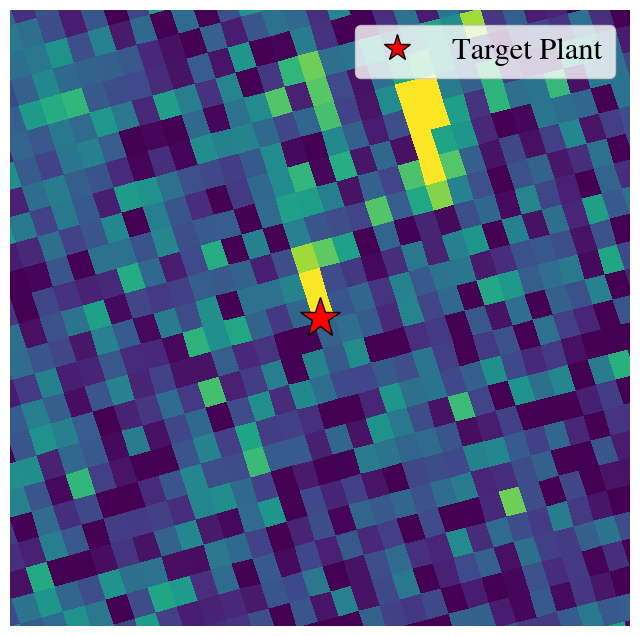

  saved /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/no2_65.png


In [15]:
# ─────────────────────────────────────────────────────────────────────────
# Panel 1: Plain NO₂ + target plant star
# ─────────────────────────────────────────────────────────────────────────
for idx in INDICES:
    row = df.iloc[idx]
    lat, lon, no2 = load_swath(row['file_path'])
    x_min, x_max = row['longitude'] - BOX_DEG, row['longitude'] + BOX_DEG
    y_min, y_max = row['latitude']  - BOX_DEG, row['latitude']  + BOX_DEG
    sl = slice_window(lat, lon, x_min, x_max, y_min, y_max)
    if sl is None:
        print(f'No data in window for index {idx}'); continue
    r0, r1, c0, c1 = sl

    plt.figure(figsize=(8, 8))
    plt.pcolormesh(lon[r0:r1+1, c0:c1+1], lat[r0:r1+1, c0:c1+1], no2[r0:r1+1, c0:c1+1],
                   cmap='viridis', vmin=1e-5, vmax=5e-5)
    plt.plot(row['longitude'], row['latitude'], 'r*',
             markersize=30, markeredgecolor='k', zorder=5)
    plt.xlim(x_min, x_max); plt.ylim(y_min, y_max)
    plt.legend(handles=[plt.Line2D([0], [0], marker='*', markerfacecolor='red',
                                   markeredgecolor='black', markersize=20,
                                   label='Target Plant', linestyle='')],
               loc='upper right', frameon=True, facecolor='white',
               framealpha=0.8, prop=prop)
    plt.axis('off')
    for s in plt.gca().spines.values(): s.set_visible(False)
    out = os.path.join(OUTPUT_DIR, f'no2_{idx}.png')
    plt.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()
    print(f'  saved {out}')


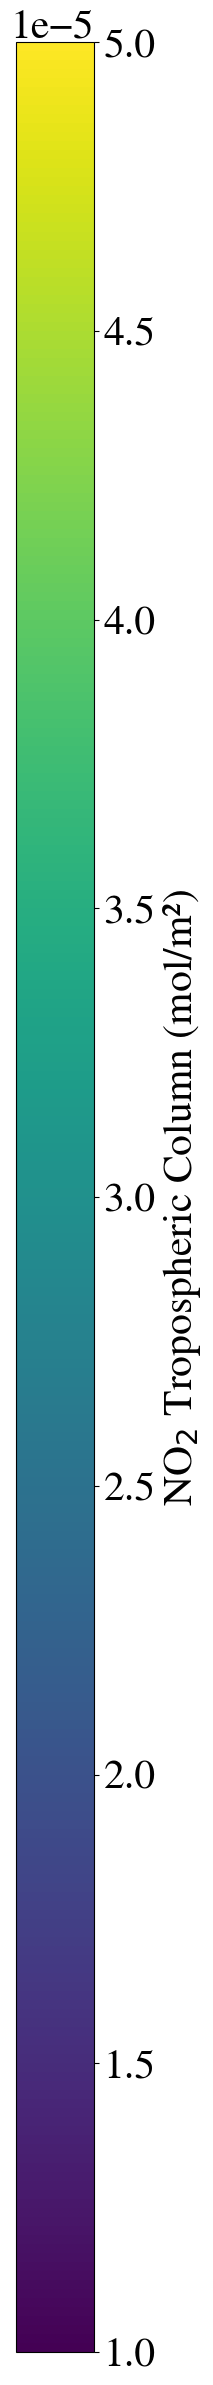

saved /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/colorbar_no2_vertical.png


In [16]:
# ─────────────────────────────────────────────────────────────────────────
# Standalone vertical colorbar for paper assembly
# ─────────────────────────────────────────────────────────────────────────
label_prop = fm.FontProperties(fname=nimbus_path, size=30) if nimbus_path else fm.FontProperties(size=22)
tick_prop  = fm.FontProperties(fname=nimbus_path, size=30) if nimbus_path else fm.FontProperties(size=18)

fig, ax = plt.subplots(figsize=(1, 30))
norm = mcolors.Normalize(vmin=1e-5, vmax=5e-5)
sm = cm.ScalarMappable(norm=norm, cmap='viridis')
sm.set_array([])
cbar = plt.colorbar(sm, cax=ax, orientation='vertical')
cbar.set_label('NO$_2$ Tropospheric Column (mol/m²)', fontproperties=label_prop)
for label in cbar.ax.get_yticklabels():
    label.set_fontproperties(tick_prop)
cbar.ax.yaxis.get_offset_text().set_fontproperties(tick_prop)

out = os.path.join(OUTPUT_DIR, 'colorbar_no2_vertical.png')
plt.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()
print(f'saved {out}')


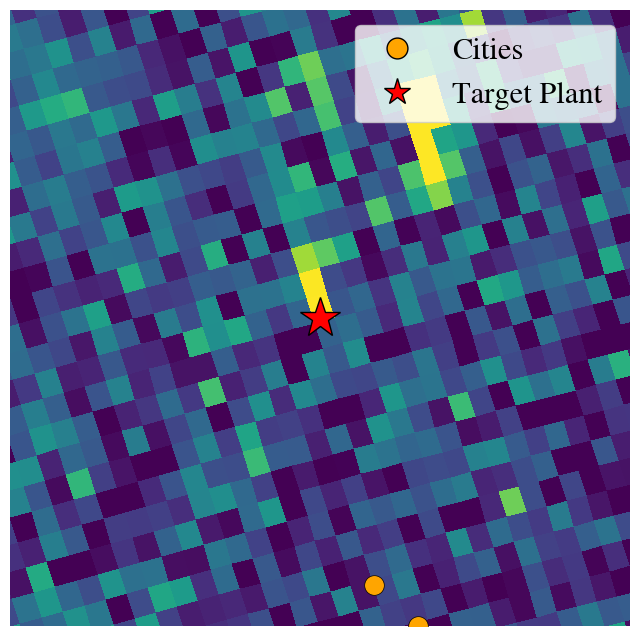

  saved /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/no2_with_cities_65.png  (interfering cities=2, plants=2)


In [17]:
# ─────────────────────────────────────────────────────────────────────────
# Panel 2: NO₂ + nearby cities
# ─────────────────────────────────────────────────────────────────────────
for idx in INDICES:
    row = df.iloc[idx]
    lat, lon, no2 = load_swath(row['file_path'])
    x_min, x_max = row['longitude'] - BOX_DEG, row['longitude'] + BOX_DEG
    y_min, y_max = row['latitude']  - BOX_DEG, row['latitude']  + BOX_DEG
    sl = slice_window(lat, lon, x_min, x_max, y_min, y_max)
    if sl is None: continue
    r0, r1, c0, c1 = sl

    ref_lat, ref_lon = row['latitude'], row['longitude']
    ref_name = resolve_target_plant_name(ref_lat, ref_lon, plants) or f'Unknown_{idx}'
    interfering = prepare_interfering_sources(ref_lat, ref_lon, ref_name, plants, cities)

    nearby_cities = cities[(cities['latitude'].between(y_min, y_max)) &
                           (cities['longitude'].between(x_min, x_max))].copy()

    plt.figure(figsize=(8, 8))
    plt.pcolormesh(lon[r0:r1+1, c0:c1+1], lat[r0:r1+1, c0:c1+1], no2[r0:r1+1, c0:c1+1],
                   cmap='viridis', vmin=1e-5, vmax=5e-5, zorder=1)
    if not nearby_cities.empty:
        plt.scatter(nearby_cities['longitude'], nearby_cities['latitude'],
                    s=200, marker='o', color='orange', edgecolor='k', linewidth=0.5, zorder=4)
    plt.plot(ref_lon, ref_lat, 'r*', markersize=30, markeredgecolor='k', zorder=5)
    plt.xlim(x_min, x_max); plt.ylim(y_min, y_max)
    plt.legend(handles=[
        plt.Line2D([0], [0], marker='o', markerfacecolor='orange',
                   markeredgecolor='black', markersize=15, label='Cities', linestyle=''),
        plt.Line2D([0], [0], marker='*', markerfacecolor='red',
                   markeredgecolor='black', markersize=20, label='Target Plant', linestyle=''),
    ], loc='upper right', frameon=True, facecolor='white', framealpha=0.8, prop=prop)
    plt.axis('off')
    for s in plt.gca().spines.values(): s.set_visible(False)
    out = os.path.join(OUTPUT_DIR, f'no2_with_cities_{idx}.png')
    plt.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()
    n_city = sum(1 for s in interfering if s['type']=='city')
    n_plant = sum(1 for s in interfering if s['type']=='plant')
    print(f'  saved {out}  (interfering cities={n_city}, plants={n_plant})')


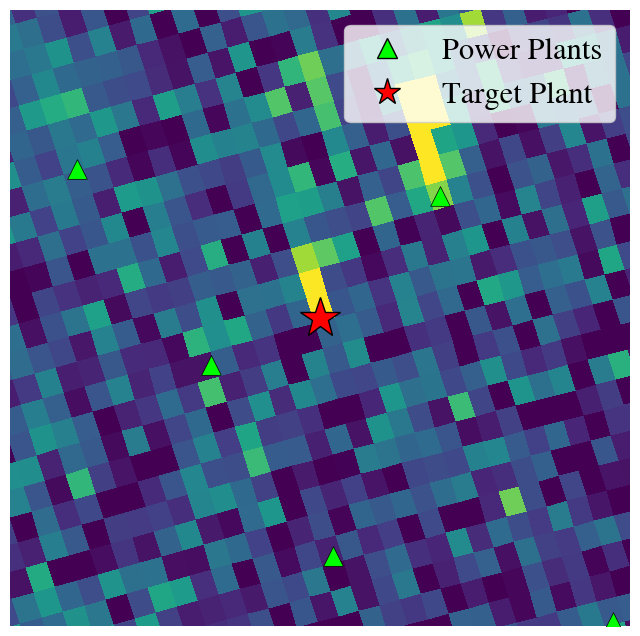

  saved /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/no2_with_power_plants_65.png


In [18]:
# ─────────────────────────────────────────────────────────────────────────
# Panel 3: NO₂ + nearby power plants
# ─────────────────────────────────────────────────────────────────────────
for idx in INDICES:
    row = df.iloc[idx]
    lat, lon, no2 = load_swath(row['file_path'])
    x_min, x_max = row['longitude'] - BOX_DEG, row['longitude'] + BOX_DEG
    y_min, y_max = row['latitude']  - BOX_DEG, row['latitude']  + BOX_DEG
    sl = slice_window(lat, lon, x_min, x_max, y_min, y_max)
    if sl is None: continue
    r0, r1, c0, c1 = sl

    ref_lat, ref_lon = row['latitude'], row['longitude']
    ref_name = resolve_target_plant_name(ref_lat, ref_lon, plants) or f'Unknown_{idx}'

    plants_mask = (plants['Latitude'].between(y_min, y_max) &
                   plants['Longitude'].between(x_min, x_max))
    if ref_name and not ref_name.startswith('Unknown'):
        plants_mask &= (plants['Facility Name'] != ref_name)
    else:
        plants_mask &= ~((np.abs(plants['Latitude'] - ref_lat) < 1e-4) &
                         (np.abs(plants['Longitude'] - ref_lon) < 1e-4))
    nearby_plants = plants[plants_mask].copy()

    plt.figure(figsize=(8, 8))
    plt.pcolormesh(lon[r0:r1+1, c0:c1+1], lat[r0:r1+1, c0:c1+1], no2[r0:r1+1, c0:c1+1],
                   cmap='viridis', vmin=1e-5, vmax=5e-5, zorder=1)
    if not nearby_plants.empty:
        plt.scatter(nearby_plants['Longitude'], nearby_plants['Latitude'],
                    s=200, marker='^', color='#00FF00', edgecolor='k', linewidth=0.5, zorder=4)
    plt.plot(ref_lon, ref_lat, 'r*', markersize=30, markeredgecolor='k', zorder=5)
    plt.xlim(x_min, x_max); plt.ylim(y_min, y_max)
    plt.legend(handles=[
        plt.Line2D([0], [0], marker='^', markerfacecolor='#00FF00',
                   markeredgecolor='black', markersize=15, label='Power Plants', linestyle=''),
        plt.Line2D([0], [0], marker='*', markerfacecolor='red',
                   markeredgecolor='black', markersize=20, label='Target Plant', linestyle=''),
    ], loc='upper right', frameon=True, facecolor='white', framealpha=0.8, prop=prop)
    plt.axis('off')
    for s in plt.gca().spines.values(): s.set_visible(False)
    out = os.path.join(OUTPUT_DIR, f'no2_with_power_plants_{idx}.png')
    plt.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()
    print(f'  saved {out}')


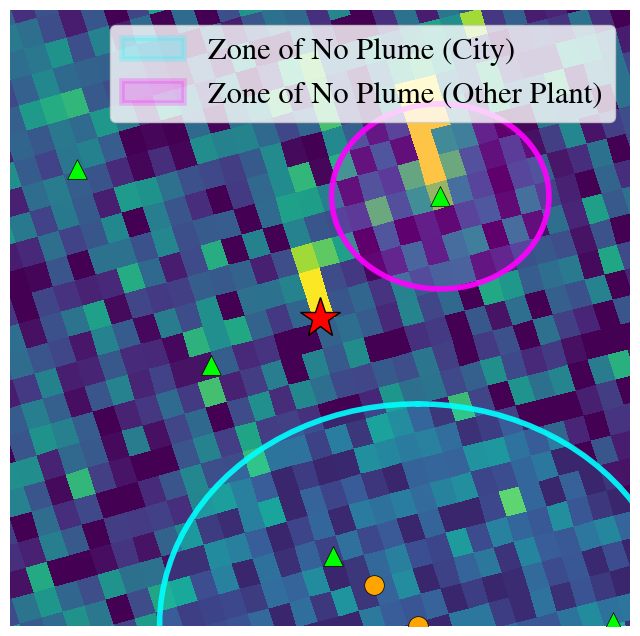

  saved /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/no2_with_interference_65.png  (interference: cities=2, plants=2)


In [19]:
# ─────────────────────────────────────────────────────────────────────────
# Panel 4: NO₂ + cities + plants + interference zones
# ─────────────────────────────────────────────────────────────────────────
for idx in INDICES:
    row = df.iloc[idx]
    lat, lon, no2 = load_swath(row['file_path'])
    x_min, x_max = row['longitude'] - BOX_DEG, row['longitude'] + BOX_DEG
    y_min, y_max = row['latitude']  - BOX_DEG, row['latitude']  + BOX_DEG
    sl = slice_window(lat, lon, x_min, x_max, y_min, y_max)
    if sl is None: continue
    r0, r1, c0, c1 = sl

    ref_lat, ref_lon = row['latitude'], row['longitude']
    ref_name = resolve_target_plant_name(ref_lat, ref_lon, plants) or f'Unknown_{idx}'
    interfering = prepare_interfering_sources(ref_lat, ref_lon, ref_name, plants, cities)

    plants_mask = (plants['Latitude'].between(y_min, y_max) &
                   plants['Longitude'].between(x_min, x_max))
    if ref_name and not ref_name.startswith('Unknown'):
        plants_mask &= (plants['Facility Name'] != ref_name)
    nearby_plants = plants[plants_mask].copy()
    nearby_cities = cities[(cities['latitude'].between(y_min, y_max)) &
                           (cities['longitude'].between(x_min, x_max))].copy()

    plt.figure(figsize=(8, 8))
    plt.pcolormesh(lon[r0:r1+1, c0:c1+1], lat[r0:r1+1, c0:c1+1], no2[r0:r1+1, c0:c1+1],
                   cmap='viridis', vmin=1e-5, vmax=5e-5, zorder=1)

    # Interference zones
    for src in interfering:
        if src['type'] == 'city':
            cl, ca = create_geodesic_circle(src['lon'], src['lat'], src['radius_km'])
            plt.fill(cl, ca, color='cyan', alpha=0.15, zorder=2)
            plt.plot(cl, ca, color='cyan', linewidth=4, alpha=0.9, zorder=3)
        else:  # plant
            cl, ca = create_geodesic_circle(src['lon'], src['lat'], CLOSE_DISTANCE_KM_MASK)
            plt.fill(cl, ca, color='magenta', alpha=0.15, zorder=2)
            plt.plot(cl, ca, color='magenta', linewidth=4, linestyle='-', alpha=0.9, zorder=3)

    # Markers
    if not nearby_plants.empty:
        plt.scatter(nearby_plants['Longitude'], nearby_plants['Latitude'],
                    s=200, marker='^', color='#00FF00', edgecolor='k', linewidth=0.5, zorder=4)
    if not nearby_cities.empty:
        plt.scatter(nearby_cities['longitude'], nearby_cities['latitude'],
                    s=200, marker='o', color='orange', edgecolor='k', linewidth=0.5, zorder=4)
    plt.plot(ref_lon, ref_lat, 'r*', markersize=30, markeredgecolor='k', zorder=8)

    plt.xlim(x_min, x_max); plt.ylim(y_min, y_max)
    plt.legend(handles=[
        Patch(facecolor='cyan', alpha=0.2, edgecolor='cyan', linewidth=4,
              label='Zone of No Plume (City)'),
        Patch(facecolor='magenta', alpha=0.2, edgecolor='magenta', linewidth=4,
              label='Zone of No Plume (Other Plant)'),
    ], loc='upper right', frameon=True, facecolor='white', framealpha=0.8, prop=prop)
    plt.axis('off')
    for s in plt.gca().spines.values(): s.set_visible(False)
    out = os.path.join(OUTPUT_DIR, f'no2_with_interference_{idx}.png')
    plt.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()
    n_city = sum(1 for s in interfering if s['type']=='city')
    n_plant = sum(1 for s in interfering if s['type']=='plant')
    print(f'  saved {out}  (interference: cities={n_city}, plants={n_plant})')


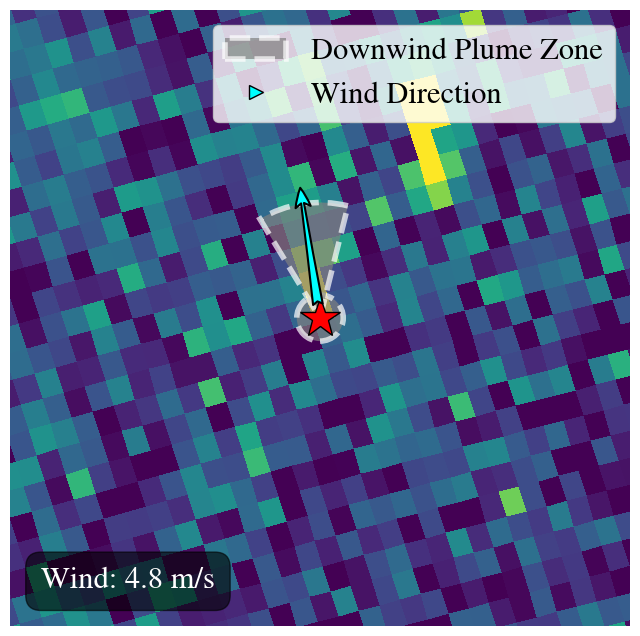

  saved /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/no2_plume_zone_65_arrow_legend.png


In [23]:
# ─────────────────────────────────────────────────────────────────────────
# Panel 5: NO₂ + downwind plume zone (5 km circle ⊕ 25 km wedge) + wind arrow
# ─────────────────────────────────────────────────────────────────────────
NEAR_RADIUS_KM = 5.0
PLUME_RADIUS_KM = 25.0
PLUME_ANGLE_SPREAD_DEG = 45.0
ZONE_STYLE = dict(facecolor='gray', alpha=0.7, edgecolor='white',
                  linestyle='--', linewidth=4, zorder=2)
ARROW_LEN_FACTOR = 1.2          # multiplier on PLUME_RADIUS_KM for arrow length
ARROW_STYLE = 'fancy,head_length=1.4,head_width=1.1,tail_width=0.7'

for idx in INDICES:
    row = df.iloc[idx]
    wind_u, wind_v = row.get('wind_u'), row.get('wind_v')
    has_wind = pd.notna(wind_u) and pd.notna(wind_v) and not (wind_u == 0 and wind_v == 0)
    if has_wind:
        wind_to_rad = np.arctan2(wind_v, wind_u)
        wind_to_deg = np.degrees(wind_to_rad)
        wind_from_deg = (270 - wind_to_deg) % 360
        wind_speed = np.sqrt(wind_u**2 + wind_v**2)

    lat, lon, no2 = load_swath(row['file_path'])
    x_min, x_max = row['longitude'] - BOX_DEG, row['longitude'] + BOX_DEG
    y_min, y_max = row['latitude']  - BOX_DEG, row['latitude']  + BOX_DEG
    sl = slice_window(lat, lon, x_min, x_max, y_min, y_max)
    if sl is None: continue
    r0, r1, c0, c1 = sl

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pcolormesh(lon[r0:r1+1, c0:c1+1], lat[r0:r1+1, c0:c1+1], no2[r0:r1+1, c0:c1+1],
                  cmap='viridis', vmin=1e-5, vmax=5e-5, zorder=1)
    ax.plot(row['longitude'], row['latitude'], 'r*',
            markersize=30, markeredgecolor='k', zorder=5)

    legend_elements = []
    if has_wind:
        # Close-range circle (5 km)
        ax.add_patch(patches.Circle((row['longitude'], row['latitude']),
                                    NEAR_RADIUS_KM / KM_PER_DEG_LAT, **ZONE_STYLE))
        # Downwind wedge (25 km, ±22.5° around wind-to direction)
        ax.add_patch(patches.Wedge(
            (row['longitude'], row['latitude']), PLUME_RADIUS_KM / KM_PER_DEG_LAT,
            wind_to_deg - PLUME_ANGLE_SPREAD_DEG / 2,
            wind_to_deg + PLUME_ANGLE_SPREAD_DEG / 2, **ZONE_STYLE))

        # Wind arrow (cyan fancy arrow from plant)
        arrow_len_deg = ARROW_LEN_FACTOR * (PLUME_RADIUS_KM / KM_PER_DEG_LAT)
        end_x = row['longitude'] + arrow_len_deg * np.cos(wind_to_rad)
        end_y = row['latitude']  + arrow_len_deg * np.sin(wind_to_rad)
        ax.annotate('', xy=(end_x, end_y), xytext=(row['longitude'], row['latitude']),
                    arrowprops=dict(arrowstyle=ARROW_STYLE,
                                    facecolor='cyan', edgecolor='black', linewidth=1.5,
                                    shrinkA=10, shrinkB=5), zorder=6)

        # Wind speed text — BOTTOM-LEFT (per user's source layout)
        ax.text(x_min + 0.05 * (x_max - x_min), y_min + 0.05 * (y_max - y_min),
                f'Wind: {wind_speed:.1f} m/s',
                ha='left', va='bottom', color='white',
                bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.5'),
                zorder=10, fontproperties=prop)

        legend_elements = [
            Patch(label='Downwind Plume Zone', **ZONE_STYLE),
            plt.Line2D([], [], color='cyan', marker='>', linestyle='None',
                       markersize=10, markeredgecolor='black', label='Wind Direction'),
        ]

    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
    if legend_elements:
        ax.legend(handles=legend_elements, loc='upper right', frameon=True,
                  facecolor='white', framealpha=0.8, prop=prop)
    ax.axis('off')
    for s in ax.spines.values(): s.set_visible(False)
    out = os.path.join(OUTPUT_DIR, f'no2_plume_zone_{idx}_arrow_legend.png')
    plt.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()
    print(f'  saved {out}')

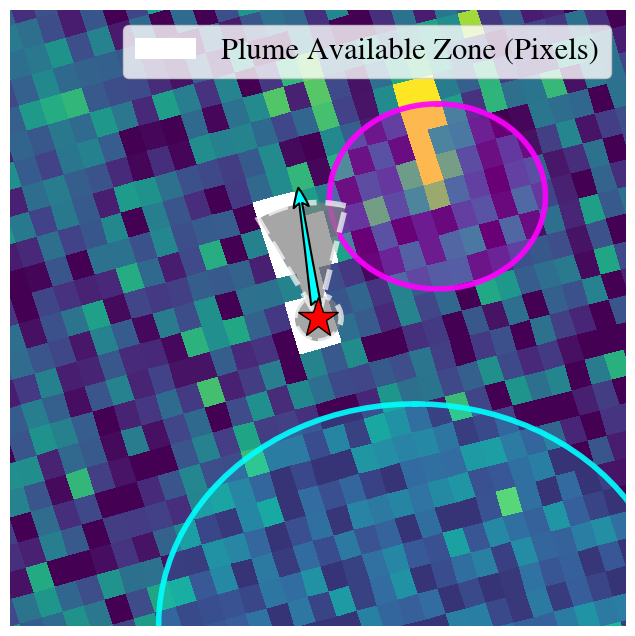

  saved /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/plume_available_zone_65.png  (13 available pixels)


In [46]:
# ─────────────────────────────────────────────────────────────────────────
# Panel 6: Plume Available Zone (yellow pixels)
#   = (downwind plume zone) ∩ ¬(zone of no plume)
# Shows the final candidate pixels for plume detection at the pixel level.
# ─────────────────────────────────────────────────────────────────────────
import matplotlib.colors as mcolors
KM_PER_DEG = KM_PER_DEG_LAT  # alias

def _src_radius_km(src):
    """Plant entries from `prepare_interfering_sources` carry radius_km=0,
    but the detection algorithm masks them out to CLOSE_DISTANCE_KM_MASK —
    use that here so plants get masked + drawn."""
    return CLOSE_DISTANCE_KM_MASK if src['type'] == 'plant' else src['radius_km']

# Stacking order (bottom → top):
#   1.0  NO₂ pcolormesh
#   1.5  Plume Available Zone (white pixels)
#   1.6  Interference fill (cyan/magenta)        ← below downwind zone
#   1.7  Interference outline (cyan/magenta)
#   2.0  Downwind plume zone (gray dashed)       ← on top
#   8.0  Wind arrow
#  12.0  Plant star

for idx in INDICES:
    row = df.iloc[idx]
    ref_lat, ref_lon = row['latitude'], row['longitude']
    wind_u, wind_v = row.get('wind_u'), row.get('wind_v')
    has_wind = pd.notna(wind_u) and pd.notna(wind_v) and not (wind_u == 0 and wind_v == 0)
    if has_wind:
        wind_to_rad = np.arctan2(wind_v, wind_u)
        wind_to_deg = np.degrees(wind_to_rad)

    lat, lon, no2 = load_swath(row['file_path'])
    x_min, x_max = ref_lon - BOX_DEG, ref_lon + BOX_DEG
    y_min, y_max = ref_lat - BOX_DEG, ref_lat + BOX_DEG
    sl = slice_window(lat, lon, x_min, x_max, y_min, y_max)
    if sl is None: continue
    r0, r1, c0, c1 = sl
    lats_g, lons_g, no2_g = lat[r0:r1+1, c0:c1+1], lon[r0:r1+1, c0:c1+1], no2[r0:r1+1, c0:c1+1]

    ref_name = resolve_target_plant_name(ref_lat, ref_lon, plants) or f'Unknown_{idx}'
    interfering = prepare_interfering_sources(ref_lat, ref_lon, ref_name, plants, cities)

    available_mask = np.zeros_like(lons_g, dtype=bool)
    if has_wind:
        # Distance + angle of every pixel from the plant
        dx = (lons_g - ref_lon) * KM_PER_DEG * np.cos(np.radians(ref_lat))
        dy = (lats_g - ref_lat) * KM_PER_DEG
        dist_km = np.sqrt(dx**2 + dy**2)

        # Downwind zone: 5 km circle ∪ 25 km wedge
        circle_mask = dist_km < NEAR_RADIUS_KM
        wedge_dist  = dist_km < PLUME_RADIUS_KM
        ang = np.degrees(np.arctan2(dy, dx))
        ang_diff = (ang - wind_to_deg + 180) % 360 - 180
        wedge_ang = np.abs(ang_diff) <= PLUME_ANGLE_SPREAD_DEG / 2
        downwind = circle_mask | (wedge_dist & wedge_ang)

        # Zone of no plume (cities + nearby plants).
        # Plants are stored with radius_km=0; use CLOSE_DISTANCE_KM_MASK.
        no_plume = np.zeros_like(lons_g, dtype=bool)
        for src in interfering:
            dx_s = (lons_g - src['lon']) * KM_PER_DEG * np.cos(np.radians(src['lat']))
            dy_s = (lats_g - src['lat']) * KM_PER_DEG
            no_plume |= (np.sqrt(dx_s**2 + dy_s**2) < _src_radius_km(src))

        available_mask = downwind & ~no_plume

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_facecolor('black')
    ax.pcolormesh(lons_g, lats_g, no2_g, cmap='viridis', vmin=1e-5, vmax=5e-5, zorder=1)

    # Plume Available Zone — highlight pixels in WHITE
    if has_wind and available_mask.any():
        highlight = np.where(available_mask, 1, np.nan)
        ax.pcolormesh(lons_g, lats_g, highlight,
                      cmap=mcolors.ListedColormap(['#FFFFFF']),
                      shading='auto', zorder=1.5)

    # Zone of no plume outlines (cyan = cities, magenta = other plants)
    # Drawn UNDER the downwind plume zone overlay
    for src in interfering:
        color = 'cyan' if src['type'] == 'city' else 'magenta'
        cl, ca = create_geodesic_circle(src['lon'], src['lat'], _src_radius_km(src))
        ax.fill(cl, ca, color=color, alpha=0.2, zorder=1.6)
        ax.plot(cl, ca, color=color, linewidth=4, alpha=0.9, zorder=1.7)

    # Downwind plume zone outline (gray dashed) — on top of interference + white pixels
    if has_wind:
        ax.add_patch(patches.Circle((ref_lon, ref_lat), NEAR_RADIUS_KM / KM_PER_DEG, **ZONE_STYLE))
        ax.add_patch(patches.Wedge((ref_lon, ref_lat), PLUME_RADIUS_KM / KM_PER_DEG,
                                   wind_to_deg - PLUME_ANGLE_SPREAD_DEG / 2,
                                   wind_to_deg + PLUME_ANGLE_SPREAD_DEG / 2, **ZONE_STYLE))

    # Wind arrow + target plant
    ax.plot(ref_lon, ref_lat, 'r*', markersize=30, markeredgecolor='k', zorder=12)
    if has_wind:
        arrow_len_deg = ARROW_LEN_FACTOR * (PLUME_RADIUS_KM / KM_PER_DEG)
        ax.annotate('', xy=(ref_lon + arrow_len_deg * np.cos(wind_to_rad),
                            ref_lat + arrow_len_deg * np.sin(wind_to_rad)),
                    xytext=(ref_lon, ref_lat),
                    arrowprops=dict(arrowstyle=ARROW_STYLE,
                                    facecolor='cyan', edgecolor='black', linewidth=1.5,
                                    shrinkA=10, shrinkB=5), zorder=8)

    ax.legend(handles=[Patch(facecolor='#FFFFFF', label='Plume Available Zone (Pixels)')],
              loc='upper right', frameon=True, facecolor='white', framealpha=0.8, prop=prop)
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')
    for s in ax.spines.values(): s.set_visible(False)
    out = os.path.join(OUTPUT_DIR, f'plume_available_zone_{idx}.png')
    plt.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()
    print(f'  saved {out}  ({int(available_mask.sum())} available pixels)')

/home/rzhuang/.conda/envs/rzhuang-env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


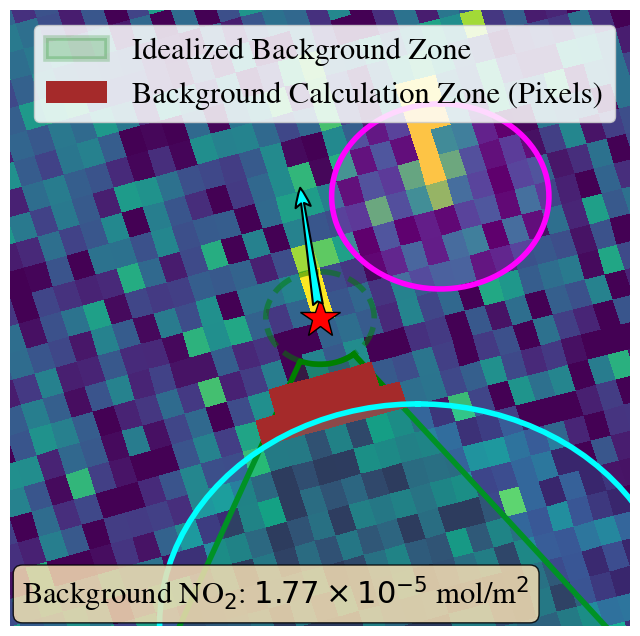

  saved /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/background_calculation_pixels_idx_65.png  (background NO2 = 1.77e-05 mol/m^2 from 21 pixels)


In [43]:
# ─────────────────────────────────────────────────────────────────────────
# Panel 7: Background Calculation Zone (10–100 km, ±30° upwind)
#   Shows the annular sector + the actual pixels used for background NO₂
#   median, with the resulting background value overlaid in the corner.
# ─────────────────────────────────────────────────────────────────────────
import numpy.ma as ma
from matplotlib import colors as mcol


def _sci_latex(x, digits=2):
    """Format x as 'm.mm \times 10^{e}' for LaTeX/mathtext rendering."""
    if pd.isna(x):
        return r'\mathrm{N/A}'
    s = f'{x:.{digits}e}'                # e.g. '1.77e-05'
    mant, exp = s.split('e')
    return rf'{mant} \times 10^{{{int(exp)}}}'


def _src_radius_km_p7(src):
    """Plant entries carry radius_km=0; use CLOSE_DISTANCE_KM_MASK."""
    return CLOSE_DISTANCE_KM_MASK if src['type'] == 'plant' else src['radius_km']


for idx in INDICES:
    row = df.iloc[idx]
    ref_lat, ref_lon = row['latitude'], row['longitude']
    wind_u, wind_v = row.get('wind_u'), row.get('wind_v')
    has_wind = pd.notna(wind_u) and pd.notna(wind_v) and not (wind_u == 0 and wind_v == 0)
    wind_from_deg = np.nan
    if has_wind:
        # Math-style wind-to direction (matches Panel 5 convention)
        wind_to_rad = np.arctan2(wind_v, wind_u)
        wind_to_deg = np.degrees(wind_to_rad)
        # Meteorological wind-from bearing (for upwind sector geometry)
        wind_from_deg = (270 - wind_to_deg) % 360

    lat, lon, no2 = load_swath(row['file_path'])
    x_min, x_max = ref_lon - BOX_DEG, ref_lon + BOX_DEG
    y_min, y_max = ref_lat - BOX_DEG, ref_lat + BOX_DEG
    sl = slice_window(lat, lon, x_min, x_max, y_min, y_max)
    if sl is None: continue
    r0, r1, c0, c1 = sl
    lat_z, lon_z, no2_z = lat[r0:r1+1, c0:c1+1], lon[r0:r1+1, c0:c1+1], no2[r0:r1+1, c0:c1+1]

    # Zone of no plume mask (per-pixel) — plants masked at CLOSE_DISTANCE_KM_MASK
    ref_name = resolve_target_plant_name(ref_lat, ref_lon, plants) or 'Unknown'
    interfering = prepare_interfering_sources(ref_lat, ref_lon, ref_name, plants, cities)
    no_plume_mask = np.zeros_like(lat_z, dtype=bool)
    geod = Geod(ellps='WGS84')
    for src in interfering:
        _, _, dist_m = geod.inv(np.full_like(lon_z, src['lon']),
                                np.full_like(lat_z, src['lat']),
                                lon_z, lat_z)
        no_plume_mask |= (dist_m / 1000.0 <= _src_radius_km_p7(src))

    # Background calc mask
    bg_mask = create_background_mask(lat_z, lon_z, ref_lat, ref_lon,
                                     wind_from_deg, no_plume_mask,
                                     BG_DIST_MIN_KM, BG_DIST_MAX_KM,
                                     BG_ANGLE_TOLERANCE_DEG)
    if bg_mask.any():
        bg_value = np.median(no2_z[bg_mask])
        bg_n = int(bg_mask.sum())
    else:
        bg_value, bg_n = np.nan, 0

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pcolormesh(lon_z, lat_z, no2_z, cmap='viridis', vmin=1e-5, vmax=5e-5,
                  zorder=1, shading='auto')

    # Background calculation pixels (BROWN)
    if bg_mask.any():
        m = ma.masked_where(~bg_mask, bg_mask)
        ax.pcolormesh(lon_z, lat_z, m.astype(float),
                      cmap=mcol.ListedColormap(['brown']),
                      alpha=1.0, zorder=4, shading='auto')

    # Idealized background sector (GREEN annular sector)
    if not pd.isna(wind_from_deg):
        bnd_lon, bnd_lat = create_annular_sector_boundary(
            ref_lon, ref_lat, BG_DIST_MIN_KM, BG_DIST_MAX_KM,
            wind_from_deg, BG_ANGLE_TOLERANCE_DEG)
        ax.fill(bnd_lon, bnd_lat, color='green', alpha=0.2, zorder=2)
        ax.plot(bnd_lon, bnd_lat, color='green', linewidth=4, zorder=3)

        inner_lon, inner_lat = create_geodesic_circle(ref_lon, ref_lat, BG_DIST_MIN_KM, 200)
        outer_lon, outer_lat = create_geodesic_circle(ref_lon, ref_lat, BG_DIST_MAX_KM, 200)
        ax.plot(inner_lon, inner_lat, 'g--', linewidth=4, alpha=0.5, zorder=2)
        ax.plot(outer_lon, outer_lat, 'g--', linewidth=4, alpha=0.5, zorder=2)

    # Zone of no plume outlines (cyan = cities, magenta = other plants)
    for src in interfering:
        color = 'cyan' if src['type'] == 'city' else 'magenta'
        cl, ca = create_geodesic_circle(src['lon'], src['lat'], _src_radius_km_p7(src))
        ax.fill(cl, ca, color=color, alpha=0.15, zorder=6)
        ax.plot(cl, ca, color=color, linewidth=4, zorder=7)

    # Target plant + wind arrow (cyan, downwind direction — matches Panel 5)
    ax.plot(ref_lon, ref_lat, 'r*', markersize=30, markeredgecolor='k', zorder=8)
    if has_wind:
        arrow_len_deg = ARROW_LEN_FACTOR * (PLUME_RADIUS_KM / KM_PER_DEG_LAT)
        end_x = ref_lon + arrow_len_deg * np.cos(wind_to_rad)
        end_y = ref_lat + arrow_len_deg * np.sin(wind_to_rad)
        ax.annotate('', xy=(end_x, end_y), xytext=(ref_lon, ref_lat),
                    arrowprops=dict(arrowstyle=ARROW_STYLE,
                                    facecolor='cyan', edgecolor='black', linewidth=1.5,
                                    shrinkA=10, shrinkB=5), zorder=9)

    # Background NO₂ value — BOTTOM-LEFT (proper scientific notation)
    if not np.isnan(bg_value):
        bg_text = rf'Background NO$_2$: ${_sci_latex(bg_value)}$ mol/m$^2$'
    else:
        bg_text = 'Background NO$_2$: N/A'
    ax.text(0.02, 0.02, bg_text, transform=ax.transAxes,
            va='bottom', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.85),
            zorder=10, fontproperties=prop)

    legend = ax.legend(handles=[
        Patch(facecolor='green', alpha=0.2, edgecolor='green', linewidth=4,
              label='Idealized Background Zone'),
        Patch(facecolor='brown', alpha=1, label='Background Calculation Zone (Pixels)'),
    ], loc='upper right', frameon=True, facecolor='white', framealpha=0.85, prop=prop)
    legend.set_zorder(15)

    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
    ax.axis('off')
    for s in ax.spines.values(): s.set_visible(False)
    out = os.path.join(OUTPUT_DIR, f'background_calculation_pixels_idx_{idx}.png')
    plt.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()
    print(f"  saved {out}  (background NO2 = {bg_value:.2e} mol/m^2 from {bg_n} pixels)")

/home/rzhuang/.conda/envs/rzhuang-env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/rzhuang/.conda/envs/rzhuang-env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/rzhuang/.conda/envs/rzhuang-env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


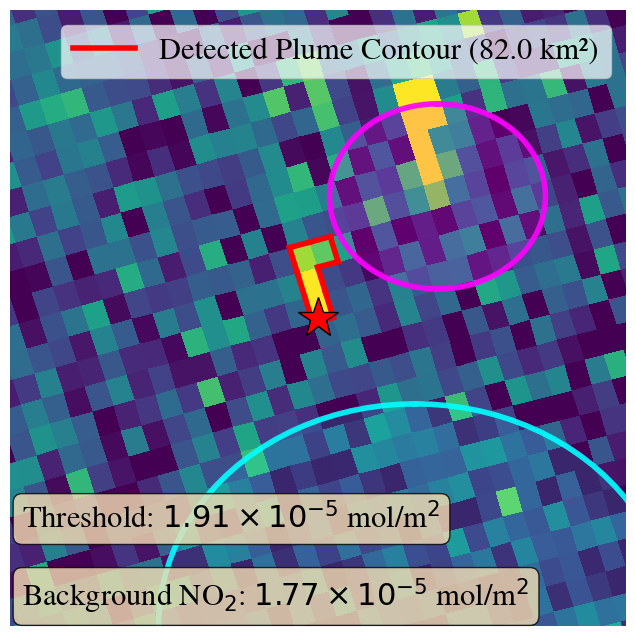

  saved /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/plume_detected_idx_65.png  (plume area=82.0 km², significant=True, threshold=1.91e-05)


In [48]:
# ─────────────────────────────────────────────────────────────────────────
# Panel 8: Detected plume — red contour tracing pixel boundaries
#   Runs label_no2_plume_flexible_interference and outlines the resulting
#   plume_mask in red along TROPOMI pixel edges (no fill). Adds background
#   NO₂ + threshold text boxes. Legend shows only the contour entry.
# ─────────────────────────────────────────────────────────────────────────
from types import SimpleNamespace
from matplotlib.lines import Line2D
from scipy import ndimage as _ndi

ALGO_ARGS = SimpleNamespace(
    box_deg=BOX_DEG,
    zoom_radius_km=sqrt(2) * BOX_DEG * KM_PER_DEG_LAT,  # ~94 km for box_deg=0.6
    threshold_factor=2.0,
    threshold_abs_min=5e-6,
    threshold_radius_km=50.0,
    max_distance_km=20.0,
    close_distance_km=5.0,
    max_angle_diff=25.0,
    flagged_area=25.0,
    background_mode='directional',
    upwind_angle_tolerance=BG_ANGLE_TOLERANCE_DEG,
    background_dist_min_km=BG_DIST_MIN_KM,
    background_dist_max_km=BG_DIST_MAX_KM,
    sigma=10.0,
    max_angle_diff_mask=0.0,
    close_distance_km_mask=CLOSE_DISTANCE_KM_MASK,
    stat_radius=50.0,
)


def _sci_latex(x, digits=2):
    """Format x as 'm.mm \\times 10^{e}' for LaTeX/mathtext rendering."""
    if pd.isna(x):
        return r'\mathrm{N/A}'
    s = f'{x:.{digits}e}'
    mant, exp = s.split('e')
    return rf'{mant} \times 10^{{{int(exp)}}}'


def _pixel_corners(z_lon, z_lat):
    """Estimate (rows+1, cols+1) corner grid from pixel centres."""
    rows, cols = z_lon.shape
    lon_c = np.zeros((rows + 1, cols + 1))
    lat_c = np.zeros((rows + 1, cols + 1))
    for i in range(1, rows):
        for j in range(1, cols):
            lon_c[i, j] = 0.25 * (z_lon[i-1, j-1] + z_lon[i-1, j] +
                                  z_lon[i,   j-1] + z_lon[i,   j])
            lat_c[i, j] = 0.25 * (z_lat[i-1, j-1] + z_lat[i-1, j] +
                                  z_lat[i,   j-1] + z_lat[i,   j])
    for j in range(1, cols):
        lon_c[0, j] = (0.5 * (z_lon[0, j-1] + z_lon[0, j]) -
                       0.5 * (lon_c[1, j] - z_lon[0, j-1:j+1].mean()))
        lat_c[0, j] = (0.5 * (z_lat[0, j-1] + z_lat[0, j]) -
                       0.5 * (lat_c[1, j] - z_lat[0, j-1:j+1].mean()))
        lon_c[rows, j] = (0.5 * (z_lon[rows-1, j-1] + z_lon[rows-1, j]) +
                          0.5 * (z_lon[rows-1, j-1:j+1].mean() - lon_c[rows-1, j]))
        lat_c[rows, j] = (0.5 * (z_lat[rows-1, j-1] + z_lat[rows-1, j]) +
                          0.5 * (z_lat[rows-1, j-1:j+1].mean() - lat_c[rows-1, j]))
    for i in range(1, rows):
        lon_c[i, 0] = (0.5 * (z_lon[i-1, 0] + z_lon[i, 0]) -
                       0.5 * (lon_c[i, 1] - z_lon[i-1:i+1, 0].mean()))
        lat_c[i, 0] = (0.5 * (z_lat[i-1, 0] + z_lat[i, 0]) -
                       0.5 * (lat_c[i, 1] - z_lat[i-1:i+1, 0].mean()))
        lon_c[i, cols] = (0.5 * (z_lon[i-1, cols-1] + z_lon[i, cols-1]) +
                          0.5 * (z_lon[i-1:i+1, cols-1].mean() - lon_c[i, cols-1]))
        lat_c[i, cols] = (0.5 * (z_lat[i-1, cols-1] + z_lat[i, cols-1]) +
                          0.5 * (z_lat[i-1:i+1, cols-1].mean() - lat_c[i, cols-1]))
    lon_c[0, 0]       = z_lon[0, 0]               - 0.5 * (lon_c[1, 1]           - z_lon[0, 0])
    lat_c[0, 0]       = z_lat[0, 0]               - 0.5 * (lat_c[1, 1]           - z_lat[0, 0])
    lon_c[0, cols]    = z_lon[0, cols-1]          + 0.5 * (z_lon[0, cols-1]      - lon_c[1, cols-1])
    lat_c[0, cols]    = z_lat[0, cols-1]          + 0.5 * (z_lat[0, cols-1]      - lat_c[1, cols-1])
    lon_c[rows, 0]    = z_lon[rows-1, 0]          + 0.5 * (z_lon[rows-1, 0]      - lon_c[rows-1, 1])
    lat_c[rows, 0]    = z_lat[rows-1, 0]          + 0.5 * (z_lat[rows-1, 0]      - lat_c[rows-1, 1])
    lon_c[rows, cols] = z_lon[rows-1, cols-1]     + 0.5 * (z_lon[rows-1, cols-1] - lon_c[rows-1, cols-1])
    lat_c[rows, cols] = z_lat[rows-1, cols-1]     + 0.5 * (z_lat[rows-1, cols-1] - lat_c[rows-1, cols-1])
    return lon_c, lat_c


def _draw_plume_contour(ax, plume_mask, z_lon, z_lat, color='red', linewidth=4.0, zorder=5):
    """Trace plume_mask boundary along TROPOMI pixel edges."""
    if not np.any(plume_mask) or z_lon.ndim != 2 or z_lat.ndim != 2:
        return
    rows, cols = plume_mask.shape
    lon_c, lat_c = _pixel_corners(z_lon, z_lat)
    labeled, n_feat = _ndi.label(plume_mask)
    for fid in range(1, n_feat + 1):
        feat = (labeled == fid)
        edges = []
        for i in range(rows):
            for j in range(cols):
                if not feat[i, j]: continue
                if i == 0 or not feat[i-1, j]:
                    edges.append(((lon_c[i, j],     lat_c[i, j]),
                                  (lon_c[i, j+1],   lat_c[i, j+1])))
                if i == rows-1 or not feat[i+1, j]:
                    edges.append(((lon_c[i+1, j],   lat_c[i+1, j]),
                                  (lon_c[i+1, j+1], lat_c[i+1, j+1])))
                if j == 0 or not feat[i, j-1]:
                    edges.append(((lon_c[i, j],     lat_c[i, j]),
                                  (lon_c[i+1, j],   lat_c[i+1, j])))
                if j == cols-1 or not feat[i, j+1]:
                    edges.append(((lon_c[i, j+1],   lat_c[i, j+1]),
                                  (lon_c[i+1, j+1], lat_c[i+1, j+1])))
        for (x1, y1), (x2, y2) in edges:
            ax.plot([x1, x2], [y1, y2], color=color, linewidth=linewidth, zorder=zorder)


for idx in INDICES:
    row = df.iloc[idx]
    ref_lat, ref_lon = row['latitude'], row['longitude']
    wind_u, wind_v = row.get('wind_u'), row.get('wind_v')

    lat_full, lon_full, no2_full = load_swath(row['file_path'])

    ref_name = resolve_target_plant_name(ref_lat, ref_lon, plants) or f'Unknown_{idx}'
    interfering = prepare_interfering_sources(ref_lat, ref_lon, ref_name, plants, cities)

    results = label_no2_plume_flexible_interference(
        full_no2=no2_full, full_lon=lon_full, full_lat=lat_full,
        wind_u=wind_u, wind_v=wind_v,
        plant_lon=ref_lon, plant_lat=ref_lat,
        interfering_sources=interfering,
        **vars(ALGO_ARGS),
    )

    z_lon, z_lat, z_no2 = results['zoomed_lons'], results['zoomed_lats'], results['zoomed_no2']
    plume_mask = results['plume_mask']
    plume_area = results['plume_area_km2']
    is_sig = results['is_significant']

    fig, ax = plt.subplots(figsize=(8, 8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('lightgray')

    if z_no2.size > 0:
        ax.pcolormesh(z_lon, z_lat, z_no2, cmap='viridis', shading='auto',
                      zorder=1, vmin=1e-5, vmax=5e-5)

        if is_sig:
            _draw_plume_contour(ax, plume_mask, z_lon, z_lat,
                                color='red', linewidth=4.0, zorder=5)

    # Interference zones
    city_plotted = plant_plotted = False
    for src in interfering:
        s_lon, s_lat = src['lon'], src['lat']
        if src['type'] == 'city':
            cl, ca = create_geodesic_circle(s_lon, s_lat, src['radius_km'])
            ax.fill(cl, ca, color='cyan', alpha=0.15, zorder=2)
            ax.plot(cl, ca, color='cyan', linewidth=4, alpha=0.9, zorder=3)
            city_plotted = True
        else:
            cl, ca = create_geodesic_circle(s_lon, s_lat, ALGO_ARGS.close_distance_km_mask)
            ax.fill(cl, ca, color='magenta', alpha=0.15, zorder=2)
            ax.plot(cl, ca, color='magenta', linewidth=4, alpha=0.9, zorder=3)
            plant_plotted = True

    # Target plant
    ax.plot(ref_lon, ref_lat, 'r*', markersize=30, markeredgecolor='k', zorder=6)

    x_min, x_max = ref_lon - BOX_DEG, ref_lon + BOX_DEG
    y_min, y_max = ref_lat - BOX_DEG, ref_lat + BOX_DEG
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')

    # ── Background NO₂ + Threshold text boxes (proper scientific notation) ─
    text_bbox = dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.8)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        bg_val = np.nanmean(results.get('background'))
    bg_text = (rf'Background NO$_2$: ${_sci_latex(bg_val)}$ mol/m$^2$'
               if not np.isnan(bg_val) else 'Background NO$_2$: N/A')
    ax.text(0.02, 0.08, bg_text, transform=ax.transAxes,
            va='top', ha='left', bbox=text_bbox, zorder=10, fontproperties=prop)

    th_val = results.get('threshold', np.nan)
    th_text = (rf'Threshold: ${_sci_latex(th_val)}$ mol/m$^2$'
               if not np.isnan(th_val) else 'Threshold: N/A')
    ax.text(0.02, 0.20, th_text, transform=ax.transAxes,
            va='top', ha='left', bbox=text_bbox, zorder=10, fontproperties=prop)

    # ── Legend (contour only) ──────────────────────────────────────────────
    legend_handles = []
    if is_sig:
        legend_handles.append(Line2D([0], [0], color='red', linewidth=4,
                                     label=f'Detected Plume Contour ({plume_area:.1f} km²)'))
    if legend_handles:
        ax.legend(handles=legend_handles, loc='upper right', frameon=True,
                  facecolor='white', framealpha=0.7, prop=prop)

    out = os.path.join(OUTPUT_DIR, f'plume_detected_idx_{idx}.png')
    plt.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()
    print(f"  saved {out}  (plume area={plume_area:.1f} km², "
          f"significant={is_sig}, threshold={th_val:.2e})")

/home/rzhuang/.conda/envs/rzhuang-env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/rzhuang/.conda/envs/rzhuang-env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/rzhuang/.conda/envs/rzhuang-env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


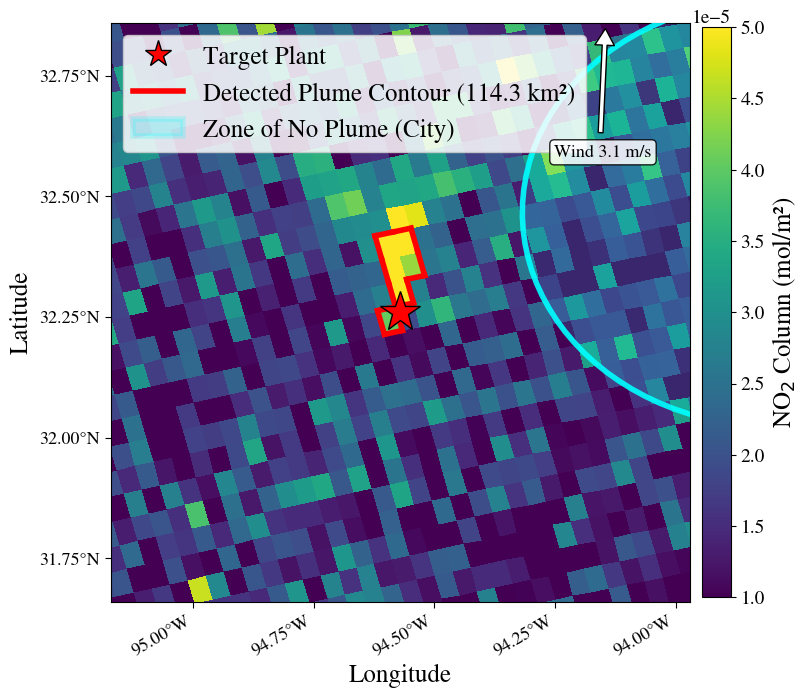

  saved /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/plume_viz_idx_48.png  (plume area=114.3 km², significant=True, cities=1, other_plants=0)
    measurement UTC time (for caption): 2022-07-26T19:25:10.618000Z


/home/rzhuang/.conda/envs/rzhuang-env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/rzhuang/.conda/envs/rzhuang-env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/rzhuang/.conda/envs/rzhuang-env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


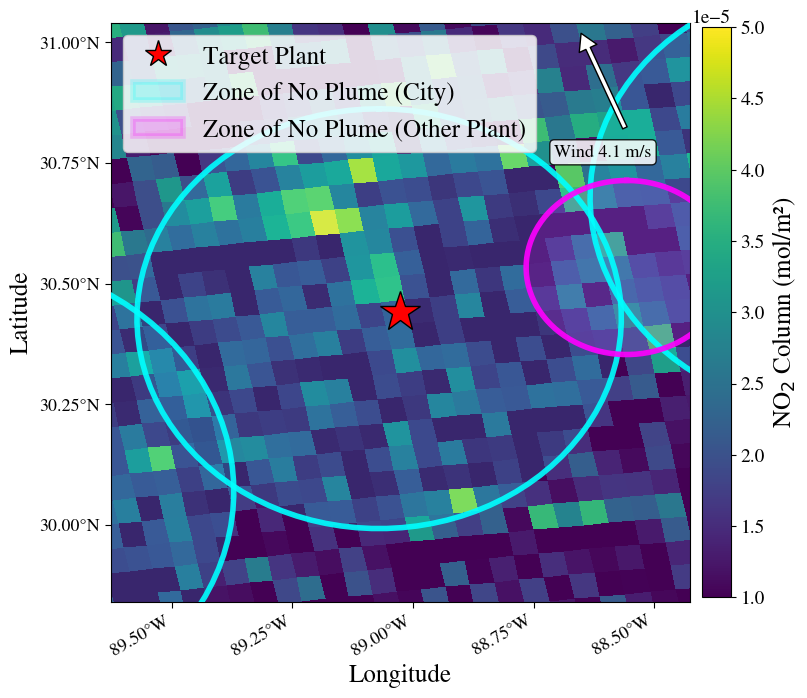

  saved /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/plume_viz_idx_73.png  (plume area=0.0 km², significant=False, cities=1, other_plants=1)
    measurement UTC time (for caption): 2022-07-26T19:24:26.939000Z

── Measurement dates for Fig. 5 caption ──
  panel idx 48: 2022-07-26T19:25:10.618000Z
  panel idx 73: 2022-07-26T19:24:26.939000Z


In [11]:
# ─────────────────────────────────────────────────────────────────────────
# Panel 9: Detected plume — reference-style layout
#   Reproduces the styling of TROPOMI_US/code/tropomi_plots_output/
#   plume_viz_idx_{40,65}.png:
#     • vertical NO₂ colorbar on the right (1e-5 .. 5e-5)
#     • lon/lat tick labels on x/y axes
#     • white wind-direction arrow (points downwind) with speed annotation
#     • full dynamic legend in the upper-left:
#         - Target Plant (red star)
#         - Detected Plume Contour (X km²)         [if is_significant]
#         - Zone of No Plume (City)                [if any cities]
#         - Zone of No Plume (Other Plant)         [if any plants]
#   Also prints the UTC measurement timestamp of each panel for the caption.
# ─────────────────────────────────────────────────────────────────────────
from matplotlib.ticker import ScalarFormatter, MaxNLocator, FuncFormatter

# Render the LST-fixed analogues of the OLD plume_viz_idx_{40,65}.png
# reference images. The mapping was determined by (lat, lon, utc_time):
#   OLD 40 (Martin Lake, 32.2597 / -94.5703) → NEW 48
#   OLD 65 (Watson E.,   30.4408 / -89.0265) → NEW 73
PANEL9_INDICES = [48, 73]   # OLD csv idx 40 → 48 (Martin Lake, plant 6146); OLD 65 → 73 (Watson Electric, plant 2049)

# Smaller font for legend so all entries fit in upper-left
panel9_legend_prop = (fm.FontProperties(fname=nimbus_path, size=18)
                      if nimbus_path else fm.FontProperties(size=18))
panel9_cbar_label_prop = (fm.FontProperties(fname=nimbus_path, size=18)
                          if nimbus_path else fm.FontProperties(size=18))
panel9_cbar_tick_prop = (fm.FontProperties(fname=nimbus_path, size=14)
                         if nimbus_path else fm.FontProperties(size=14))
panel9_axis_label_prop = (fm.FontProperties(fname=nimbus_path, size=18)
                          if nimbus_path else fm.FontProperties(size=18))
panel9_axis_tick_prop = (fm.FontProperties(fname=nimbus_path, size=13)
                         if nimbus_path else fm.FontProperties(size=13))

def _lon_fmt(x, _):
    return f"{abs(x):.2f}°{'E' if x >= 0 else 'W'}"
def _lat_fmt(y, _):
    return f"{abs(y):.2f}°{'N' if y >= 0 else 'S'}"

caption_dates = {}  # idx -> UTC timestamp string, for the figure caption

for idx in PANEL9_INDICES:
    if idx >= len(df):
        print(f'  idx {idx} out of range (len(df)={len(df)})'); continue

    row = df.iloc[idx]
    ref_lat, ref_lon = row['latitude'], row['longitude']
    wind_u, wind_v = row.get('wind_u'), row.get('wind_v')

    lat_full, lon_full, no2_full = load_swath(row['file_path'])

    ref_name = resolve_target_plant_name(ref_lat, ref_lon, plants) or f'Unknown_{idx}'
    interfering = prepare_interfering_sources(ref_lat, ref_lon, ref_name, plants, cities)

    results = label_no2_plume_flexible_interference(
        full_no2=no2_full, full_lon=lon_full, full_lat=lat_full,
        wind_u=wind_u, wind_v=wind_v,
        plant_lon=ref_lon, plant_lat=ref_lat,
        interfering_sources=interfering,
        **vars(ALGO_ARGS),
    )

    z_lon, z_lat, z_no2 = results['zoomed_lons'], results['zoomed_lats'], results['zoomed_no2']
    plume_mask = results['plume_mask']
    plume_area = results['plume_area_km2']
    is_sig = results['is_significant']

    fig, ax = plt.subplots(figsize=(8, 8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('lightgray')

    im = None
    if z_no2.size > 0:
        im = ax.pcolormesh(z_lon, z_lat, z_no2, cmap='viridis', shading='auto',
                           zorder=1, vmin=1e-5, vmax=5e-5)

        if is_sig:
            _draw_plume_contour(ax, plume_mask, z_lon, z_lat,
                                color='red', linewidth=4.0, zorder=5)

    # Interference zones (cyan = cities, magenta = other plants)
    city_plotted = plant_plotted = False
    for src in interfering:
        s_lon, s_lat = src['lon'], src['lat']
        if src['type'] == 'city':
            cl, ca = create_geodesic_circle(s_lon, s_lat, src['radius_km'])
            ax.fill(cl, ca, color='cyan', alpha=0.15, zorder=2)
            ax.plot(cl, ca, color='cyan', linewidth=4, alpha=0.9, zorder=3)
            city_plotted = True
        else:
            cl, ca = create_geodesic_circle(s_lon, s_lat, ALGO_ARGS.close_distance_km_mask)
            ax.fill(cl, ca, color='magenta', alpha=0.15, zorder=2)
            ax.plot(cl, ca, color='magenta', linewidth=4, alpha=0.9, zorder=3)
            plant_plotted = True

    # Target plant (red star)
    ax.plot(ref_lon, ref_lat, 'r*', markersize=30, markeredgecolor='k', zorder=6)

    # Plot bounds
    x_min, x_max = ref_lon - BOX_DEG, ref_lon + BOX_DEG
    y_min, y_max = ref_lat - BOX_DEG, ref_lat + BOX_DEG
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal', adjustable='box')

    # ── Lon/Lat axis labels and ticks ──────────────────────────────────────
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.xaxis.set_major_formatter(FuncFormatter(_lon_fmt))
    ax.yaxis.set_major_formatter(FuncFormatter(_lat_fmt))
    ax.set_xlabel('Longitude', fontproperties=panel9_axis_label_prop)
    ax.set_ylabel('Latitude', fontproperties=panel9_axis_label_prop)
    for lbl in ax.get_xticklabels():
        lbl.set_fontproperties(panel9_axis_tick_prop); lbl.set_rotation(30); lbl.set_ha('right')
    for lbl in ax.get_yticklabels():
        lbl.set_fontproperties(panel9_axis_tick_prop)
    ax.tick_params(axis='both', which='major', length=4, color='black')

    # ── Wind direction arrow (points toward the downwind direction) ────────
    if wind_u is not None and wind_v is not None and np.isfinite(wind_u) and np.isfinite(wind_v):
        wspd = float(np.hypot(float(wind_u), float(wind_v)))  # true speed (m/s) for the label
        if wspd > 0:
            # (wind_u, wind_v) = (eastward, northward) m/s = the downwind direction,
            # matching wind_to_rad = arctan2(wind_v, wind_u) used by the detection wedge.
            # The map is lon/lat with aspect='equal', so a degree of longitude is only
            # cos(lat)x a degree of latitude. Scale the east component by 1/cos(lat) so the
            # drawn arrow visually aligns with the displayed plume (same cos-lat km frame
            # the algorithm uses for its downwind wedge).
            cos_lat = float(np.cos(np.radians(ref_lat)))
            dx, dy = float(wind_u) / cos_lat, float(wind_v)
            dnorm = float(np.hypot(dx, dy))
            ux, uy = dx / dnorm, dy / dnorm
            arrow_len = 0.18  # in axes-fraction units
            cx, cy = 0.85, 0.90
            tail = (cx - 0.5 * arrow_len * ux, cy - 0.5 * arrow_len * uy)
            head = (cx + 0.5 * arrow_len * ux, cy + 0.5 * arrow_len * uy)
            ax.annotate('', xy=head, xytext=tail, xycoords='axes fraction',
                        arrowprops=dict(facecolor='white', edgecolor='black',
                                        width=3.5, headwidth=14, headlength=12),
                        zorder=7)
            ax.text(cx, cy - 0.5 * arrow_len - 0.02, f'Wind {wspd:.1f} m/s',
                    transform=ax.transAxes, ha='center', va='top',
                    fontproperties=panel9_axis_tick_prop,
                    bbox=dict(facecolor='white', edgecolor='black', alpha=0.85,
                              boxstyle='round,pad=0.25'),
                    zorder=7)

    # ── Vertical NO₂ colorbar on the right ─────────────────────────────────
    if im is not None:
        cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046, shrink=0.95)
        cbar.set_label('NO$_2$ Column (mol/m²)', fontproperties=panel9_cbar_label_prop)
        for lbl in cbar.ax.get_yticklabels():
            lbl.set_fontproperties(panel9_cbar_tick_prop)
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((0, 0))
        cbar.ax.yaxis.set_major_formatter(formatter)
        cbar.ax.yaxis.get_offset_text().set_fontproperties(panel9_cbar_tick_prop)
        cbar.update_ticks()

    # ── Full dynamic legend (matches reference idx_{40,65} layout) ─────────
    legend_handles = [Line2D([0], [0], marker='*', color='k', label='Target Plant',
                             markerfacecolor='r', markersize=20, linestyle='None')]
    if is_sig:
        legend_handles.append(Line2D([0], [0], color='red', linewidth=4,
                                     label=f'Detected Plume Contour ({plume_area:.1f} km²)'))
    if city_plotted:
        legend_handles.append(Patch(facecolor='cyan', alpha=0.2, edgecolor='cyan',
                                    linewidth=4, label='Zone of No Plume (City)'))
    if plant_plotted:
        legend_handles.append(Patch(facecolor='magenta', alpha=0.2, edgecolor='magenta',
                                    linewidth=4, label='Zone of No Plume (Other Plant)'))
    ax.legend(handles=legend_handles, loc='upper left', frameon=True,
              facecolor='white', framealpha=0.85, prop=panel9_legend_prop)

    out = os.path.join(OUTPUT_DIR, f'plume_viz_idx_{idx}.png')
    plt.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0.05, facecolor='white')
    plt.show()

    # UTC measurement timestamp for the figure caption
    meas_utc = row.get('utc_time')
    caption_dates[idx] = meas_utc
    print(f"  saved {out}  (plume area={plume_area:.1f} km², significant={is_sig}, "
          f"cities={int(city_plotted)}, other_plants={int(plant_plotted)})")
    print(f"    measurement UTC time (for caption): {meas_utc}")

# Convenience summary for the figure caption
print("\n── Measurement dates for Fig. 5 caption ──")
for idx in PANEL9_INDICES:
    if idx in caption_dates:
        print(f"  panel idx {idx}: {caption_dates[idx]}")
